# First TRS boundary operator extraction.
Created 03/24/2026

Objectives:
* Implement proposed TRS boundary operator extraction protocol, and save boundary operators somewhere.
* Verify that these are indeed the desired boundary operators.

# Package imports

In [1]:
import sys
sys.path.append("../..")

In [2]:
from functools import reduce
from itertools import combinations

In [3]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import unitary_group

In [5]:
from SPTOptimization.SymmetryActionWithBoundaryUnitaries import SymmetryActionWithBoundaryUnitaries
from SPTOptimization.Optimizers.utils import one_site_optimization

from SPTOptimization.gradients import expectation_gradient_from_environments_and_b_tensor

In [6]:
import quimb as qu
import quimb.tensor as qtn

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


# Load data

In [7]:
DATA_DIR = r"../../data/transverse_cluster_200_site_dmrg"

In [8]:
loaded_data = list()

for local_file_name in os.listdir(DATA_DIR):
    f_name = r"{}/{}".format(DATA_DIR, local_file_name, ignore_unknown=False)
    with h5py.File(f_name, 'r') as f:
        data = hdf5_io.load_from_hdf5(f)
        loaded_data.append(data)

In [9]:
b_parameters = sorted(list(d['paramters']['B'] for d in loaded_data))

In [10]:
def get_quimb_mps(tenpy_mps):
    psi_arrays = list()
    psi_arrays.append(tenpy_mps.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, tenpy_mps.L-1):
        psi_arrays.append(tenpy_mps.get_B(i).to_ndarray())
    psi_arrays.append(tenpy_mps.get_B(tenpy_mps.L-1)[..., 0].to_ndarray())
    
    out = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    return out

In [11]:
psi_dict = dict()

for b in b_parameters:
    psi = next(
        d['wavefunction']
        for d in loaded_data
        if d['paramters']['B'] == b
    )

    rounded_b = round(b, 1)
    psi_dict[rounded_b] = get_quimb_mps(psi)

# Definitions

In [12]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Y = np.array([[0,-1j],[1j,0]])
np_Z = np.array([[1,0],[0,-1]])

In [13]:
symmetry_actions = [
    [np_I, np_I],
    [np_I, np_X],
    [np_X, np_I],
    [np_X, np_X]
]

In [14]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

# Testing

In [15]:
psi = psi_dict[0]

In [16]:
symmetry_sites = list(range(80, 120))
num_boundary_sites = 2
all_sites = list(range(80-num_boundary_sites, 120+num_boundary_sites))

In [17]:
x_gate = qtn.Tensor(data=np_X, inds=('b', 'k'))

In [18]:
rho = psi.partial_trace_to_mpo(
    all_sites,
    rescale_sites=False
)

rho_2 = rho.copy()

In [19]:
rho.reindex(
    {f'{s}{i}': f'{s}{i}_1' for s in ['k', 'b'] for i in all_sites},
    inplace=True
)

rho_2.reindex(
    {f'{s}{i}': f'{s}{i}_2' for s in ['k', 'b'] for i in all_sites},
    inplace=True
)

x_gates_b = [
    x_gate.copy().reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
    for i in symmetry_sites
]

x_gates_k = [
    x_gate.copy().reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
    for i in symmetry_sites
]

In [20]:
final = qtn.tensor_core.TensorNetwork(
    [
        rho,
        rho_2,
        *x_gates_b,
        *x_gates_k
    ]
)

In [21]:
out = final.contract()

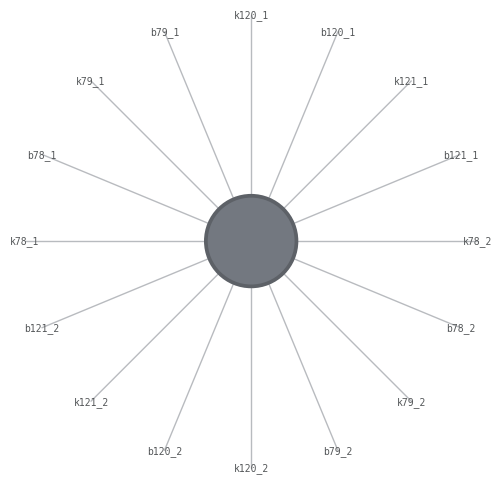

In [22]:
out.draw()

In [23]:
out.singular_values([
    'b79_1',
    'b78_1',
    'k79_1',
    'k78_1',
    'b79_2',
    'b78_2',
    'k79_2',
    'k78_2'
])

array([6.25000000e-02, 1.74760269e-17, 1.53548963e-17, 1.43942054e-17,
       1.35897981e-17, 1.22952790e-17, 1.15730191e-17, 1.15651008e-17,
       1.11119032e-17, 9.08989509e-18, 8.93113004e-18, 8.85436940e-18,
       8.73027880e-18, 7.94917436e-18, 7.71993775e-18, 7.53959895e-18,
       7.36481980e-18, 7.22003925e-18, 6.11636842e-18, 5.93041089e-18,
       5.56923104e-18, 5.37580775e-18, 4.94320512e-18, 4.79259690e-18,
       4.24608984e-18, 4.01538246e-18, 3.89742745e-18, 3.60886474e-18,
       3.56659506e-18, 3.47282588e-18, 3.41704723e-18, 2.82149673e-18,
       2.69253338e-18, 2.13240055e-18, 2.02202546e-18, 1.86408624e-18,
       1.74541907e-18, 1.41981210e-18, 1.32142586e-18, 9.79093725e-19,
       9.48605184e-19, 5.97597122e-19, 4.75778961e-19, 3.50321943e-19,
       5.59593891e-31, 3.68832833e-31, 2.15972533e-31, 1.92812443e-31,
       1.37710363e-31, 8.57969544e-32, 7.79332261e-32, 6.87844637e-32,
       5.96463896e-32, 5.54188065e-32, 5.03121860e-32, 4.68533678e-32,
      

So the left and right ''environment matrices'' decouple.

In [24]:
split_out = out.split(
    left_inds=[
        'b79_1',
        'b78_1',
        'k79_1',
        'k78_1',
        'b79_2',
        'b78_2',
        'k79_2',
        'k78_2'
    ],
    absorb=None,
    bond_ind='s'
)

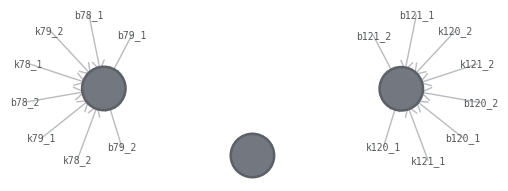

In [25]:
split_out.draw()

In [26]:
split_out.tensors[1]

Tensor(shape=(1,), inds=('s',), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']))

The decoupled diagram means that the left and right matrices effectively split.

In [27]:
left_out = split_out.tensors[0].isel({'s': 0})
right_out = split_out.tensors[2].isel({'s': 0})

Split again, see how they are coupled on either side.

In [28]:
left_out.singular_values(
    left_inds=[
        'b79_1',
        'b78_1',
        'k79_2',
        'k78_2'
    ]
)

array([0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25,
       0.25, 0.25, 0.25, 0.25, 0.25])

In [29]:
right_out

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k120_1', 'b120_1', 'k121_1', 'b121_1', 'k120_2', 'b120_2', 'k121_2', 'b121_2'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']))

In [30]:
right_out.singular_values(
    left_inds=[
        'b120_1',
        'b121_1',
        'k120_2',
        'k121_2'
    ]
)

array([0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25,
       0.25, 0.25, 0.25, 0.25, 0.25])

So each environment matrix is strongly entangled. Hm..

In [31]:
right_out

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('k120_1', 'b120_1', 'k121_1', 'b121_1', 'k120_2', 'b120_2', 'k121_2', 'b121_2'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']))

In [32]:
first_unitary = unitary_group.rvs(4)

In [33]:
first_unitary = np.reshape(first_unitary, (2,2,2,2))

In [34]:
first_unitary

array([[[[-0.10829832+0.04151845j,  0.57938718-0.17191415j],
         [-0.09135507-0.71595486j, -0.31662557-0.01071697j]],

        [[-0.54504943+0.36506182j,  0.04627525+0.17969385j],
         [-0.36621337-0.01298515j,  0.37373537-0.51113671j]]],


       [[[ 0.49009894-0.09458674j, -0.33858406-0.30884235j],
         [ 0.04640239-0.39860791j,  0.27470127-0.55166239j]],

        [[-0.12626009+0.53954931j, -0.60194129+0.16723835j],
         [ 0.15152727-0.40097393j, -0.22425063+0.26194276j]]]])

In [35]:
initial_left_boundary_op = qtn.tensor_core.Tensor(
    first_unitary,
    inds=['k120_1', 'k121_1', 'b120_2', 'b121_2']
)

ERROR! Session/line number was not unique in database. History logging moved to new session 2


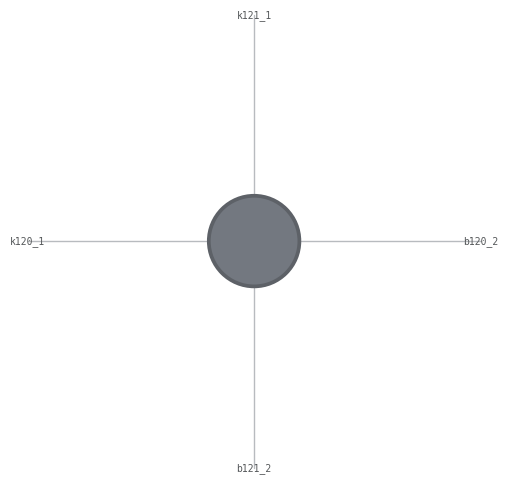

In [36]:
initial_left_boundary_op.draw()

In [37]:
partial_right_out = (initial_left_boundary_op & right_out) ^ ...

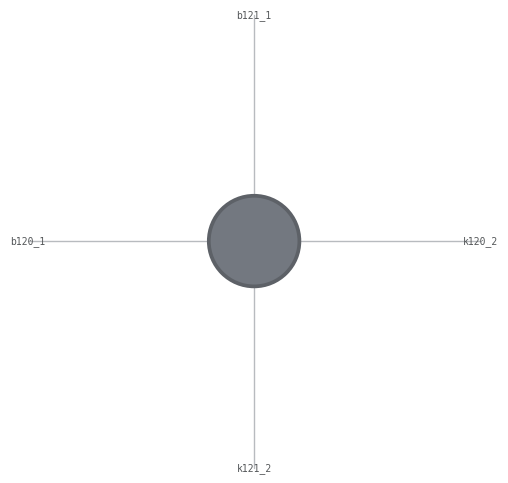

In [38]:
partial_right_out.draw()

In [39]:
svd = partial_right_out.split(
    left_inds=[
        'k120_2',
        'k121_2',
    ],
    absorb=None,
    bond_ind='s'
)

In [40]:
svd

TensorNetwork(tensors=3, indices=5)

In [41]:
svd.tensors[1].data

array([0.34726795, 0.29883264, 0.14361435, 0.13956698])

In [42]:
np.sum(svd.tensors[1].data)

0.9292819198845848

In [43]:
svd.tensors[0]

Tensor(shape=(2, 2, 4), inds=('k120_2', 'k121_2', 's'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']), left_inds=('k120_2', 'k121_2'))

In [44]:
svd.tensors[2]

Tensor(shape=(4, 2, 2), inds=('s', 'b120_1', 'b121_1'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']), left_inds=('b120_1', 'b121_1'))

In [45]:
unitary = (svd.tensors[0] & svd.tensors[2]) ^ ...

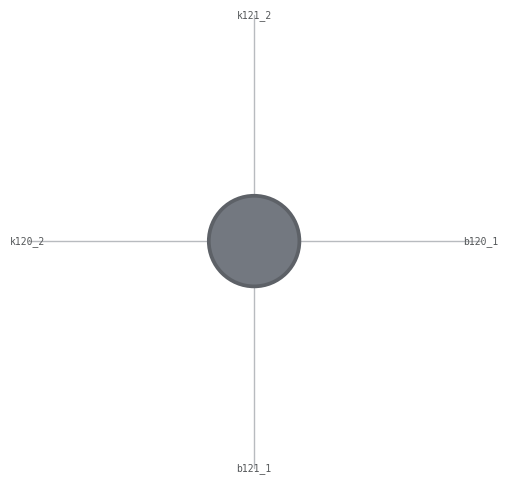

In [46]:
unitary.draw()

In [47]:
unitary = (
    unitary
    .reindex({
        'k121_2': 'b121_1',
        'k120_2': 'b120_1',
        'b121_1': 'k121_2',
        'b120_1': 'k120_2'
    })
    .conj()
)

In [48]:
unitary

Tensor(shape=(2, 2, 2, 2), inds=('b120_1', 'b121_1', 'k120_2', 'k121_2'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']))

In [49]:
partial_right_out

Tensor(shape=(2, 2, 2, 2), inds=('b120_1', 'b121_1', 'k120_2', 'k121_2'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']))

In [50]:
def svd_update(right_environment_matrix, left_boundary_guess):
    """
    Warning, lots of hard coding ahead!
    """
    partial_right_out = (left_boundary_guess & right_environment_matrix) ^ ...

    svd = partial_right_out.split(
        left_inds=[
            'k120_2',
            'k121_2',
        ],
        absorb=None,
        bond_ind='s'
    )

    first_score = np.sum(svd.tensors[1].data)
    first_unitary = (svd.tensors[0] & svd.tensors[2]) ^ ...
    first_unitary = first_unitary.conj()

    
    partial_right_out = (first_unitary & right_environment_matrix) ^ ...

    svd = partial_right_out.split(
        left_inds=[
            'k120_1',
            'k121_1',
        ],
        absorb=None,
        bond_ind='s'
    )

    second_score = np.sum(svd.tensors[1].data)
    second_unitary = (svd.tensors[0] & svd.tensors[2]) ^ ...
    second_unitary = second_unitary.conj()

    return (
        [first_unitary, second_unitary],
        [first_score, second_score]
    )

In [51]:
pair = svd_update(right_out, initial_left_boundary_op)

In [52]:
pair[1]

[0.9292819198845848, 0.9788019024214667]

In [53]:
pair[0][0]

Tensor(shape=(2, 2, 2, 2), inds=('k120_2', 'k121_2', 'b120_1', 'b121_1'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']))

In [54]:
pair[0][1]

Tensor(shape=(2, 2, 2, 2), inds=('k120_1', 'k121_1', 'b120_2', 'b121_2'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']))

In [55]:
left_boundary_op = initial_left_boundary_op
scores = list()

for _ in range(20):
    quad = svd_update(right_out, left_boundary_op)
    scores.append(quad[1])
    left_boundary_op = quad[0][1]

In [56]:
scores

[[0.9292819198845848, 0.9788019024214667],
 [0.9901030559578463, 0.9944738442730663],
 [0.9966042624469279, 0.9977893926980304],
 [0.9985063934750816, 0.9989653305412322],
 [0.9992708005457719, 0.999479826934286],
 [0.9996257236968371, 0.999729026754324],
 [0.9998029366115657, 0.9998562197110767],
 [0.9998948464730345, 0.9999229625043604],
 [0.9999434890522456, 0.9999585076568668],
 [0.9999695139885997, 0.99997758949445],
 [0.9999835197712733, 0.9999878774812649],
 [0.9999910811404837, 0.999993437192526],
 [0.9999951703349772, 0.9999964454964931],
 [0.9999973838277054, 0.9999980743716351],
 [0.9999985826000983, 0.9999989566681308],
 [0.9999992320021199, 0.9999994346686504],
 [0.9999995838497443, 0.9999996936624438],
 [0.9999997744969004, 0.9999998340006444],
 [0.9999998778027375, 0.9999999100466319],
 [0.9999999337823107, 0.999999951254886]]

In [57]:
scores = np.array(scores).flatten()

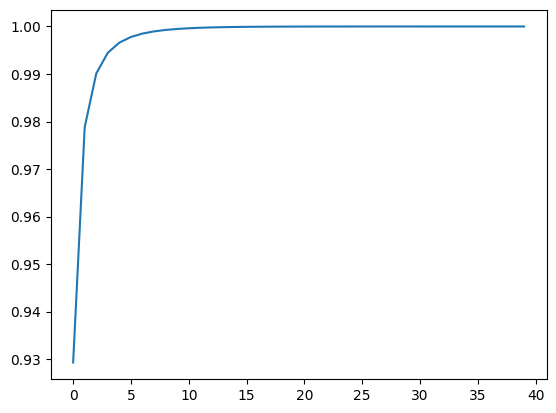

In [58]:
plt.plot(scores)

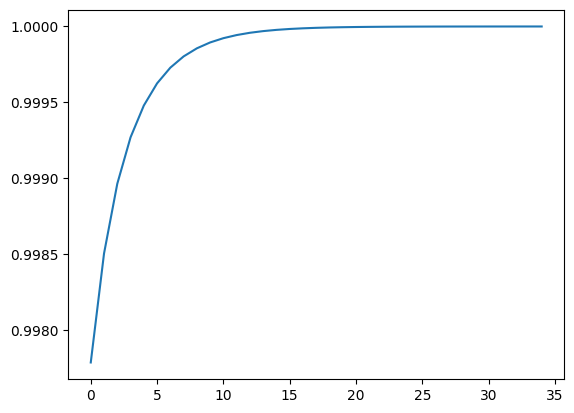

In [59]:
plt.plot(scores[5:])

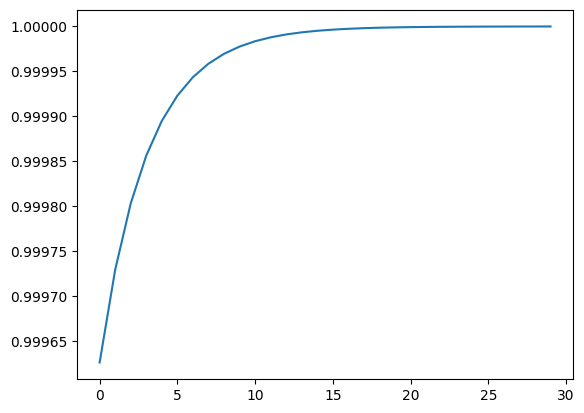

In [60]:
plt.plot(scores[10:])

Looks strictly increasing, this is good.

## Function definitions

In [122]:
def svd_update(environment_matrix, first_boundary_guess,
               first_left_inds, second_left_inds, verbose=False):
    """
    Should comment this.
    """
    if verbose:
        print('SVD')
        print('environment_matrix')
        print(environment_matrix)
        print('first_boundary_guess')
        print(first_boundary_guess)

    first_env_matrix = (first_boundary_guess & environment_matrix) ^ ...

    if verbose:
        print('first_env_matrix')
        print(first_env_matrix)

    svd = first_env_matrix.split(
        left_inds=second_left_inds,
        absorb=None,
        bond_ind='s'
    )

    first_score = np.sum(svd.tensors[1].data)
    first_unitary = (svd.tensors[0] & svd.tensors[2]) ^ ...
    first_unitary = first_unitary.conj()
    
    second_env_matrix = (first_unitary & environment_matrix) ^ ...

    svd = second_env_matrix.split(
        left_inds=first_left_inds,
        absorb=None,
        bond_ind='s'
    )

    second_score = np.sum(svd.tensors[1].data)
    second_unitary = (svd.tensors[0] & svd.tensors[2]) ^ ...
    second_unitary = second_unitary.conj()

    return (
        [first_unitary, second_unitary],
        [first_score, second_score]
    )

In [118]:
def iterated_svd_updates(environment_matrix, first_ket_inds,
                         second_ket_inds, first_bra_inds, num_iters, verbose=False):
    scores = list()

    # Hard code warning!
    rand_unitary = unitary_group.rvs(4)
    rand_unitary = np.reshape(rand_unitary, (2,2,2,2))

    boundary_guess = qtn.tensor_core.Tensor(
        rand_unitary,
        inds=first_ket_inds+first_bra_inds
    )

    for i in range(num_iters):
        if verbose:
            print(i)
            print(boundary_guess)
            print(environment_matrix)
            print(first_ket_inds)
            print(second_ket_inds)

        current_out = svd_update(
            environment_matrix,
            boundary_guess,
            first_ket_inds,
            second_ket_inds,
            verbose
        )
        scores.extend(current_out[1])
        boundary_guess = current_out[0][1]


    return (quad[0], scores)

In [138]:
def find_boundary_operators(psi, leftmost_symmetry_site,
    rightmost_symmetry_site, num_boundary_sites, num_iters):

    symmetry_sites = list(range(leftmost_symmetry_site, rightmost_symmetry_site+1))
    all_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    rho = psi.partial_trace_to_mpo(
        all_sites,
        rescale_sites=False
    )
    
    rho_2 = rho.copy()

    rho.reindex(
        {f'{s}{i}': f'{s}{i}_1' for s in ['k', 'b'] for i in all_sites},
        inplace=True
    )
    
    rho_2.reindex(
        {f'{s}{i}': f'{s}{i}_2' for s in ['k', 'b'] for i in all_sites},
        inplace=True
    )
    
    x_gates_b = [
        x_gate.copy().reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
        for i in symmetry_sites
    ]
    
    x_gates_k = [
        x_gate.copy().reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
        for i in symmetry_sites
    ]

    two_sided_environment_matrix = qtn.tensor_core.TensorNetwork(
        [
            rho,
            rho_2,
            *x_gates_b,
            *x_gates_k
        ]
    )
    two_sided_environment_matrix.contract(inplace=False)

    left_boundary_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        leftmost_symmetry_site
    ))

    right_boundary_sites = list(range(
        rightmost_symmetry_site+1,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    left_boundary_indices = [
        f'{bk}{i}_{j}'
        for bk in ['b', 'k']
        for i in left_boundary_sites
        for j in [1, 2]
    ]

    split_two_sided_environment_matrix = two_sided_environment_matrix.split(
        left_inds=left_boundary_indices,
        absorb=None,
        bond_ind='s'
    )

    two_sided_sing_vals = (
        split_two_sided_environment_matrix
        .tensors[1]
        .data
    )

    left_env_matrix = split_out.tensors[0].isel({'s': 0})
    right_env_matrix = split_out.tensors[2].isel({'s': 0})

    left_boundary_ops, left_scores = iterated_svd_updates(
        left_env_matrix,
        [f'k{i}_2' for i in left_boundary_sites],
        [f'k{i}_1' for i in left_boundary_sites],
        [f'b{i}_1' for i in left_boundary_sites],
        num_iters
    )

    right_boundary_ops, right_scores = iterated_svd_updates(
        right_env_matrix,
        [f'k{i}_2' for i in right_boundary_sites],
        [f'k{i}_1' for i in right_boundary_sites],
        [f'b{i}_1' for i in right_boundary_sites],
        num_iters
    )

    return (
        left_boundary_ops,
        right_boundary_ops,
        left_scores,
        right_scores,
        two_sided_sing_vals
    )

Test functions

In [127]:
test_quad = find_boundary_operators(
    psi,
    80,
    119,
    2,
    30
)

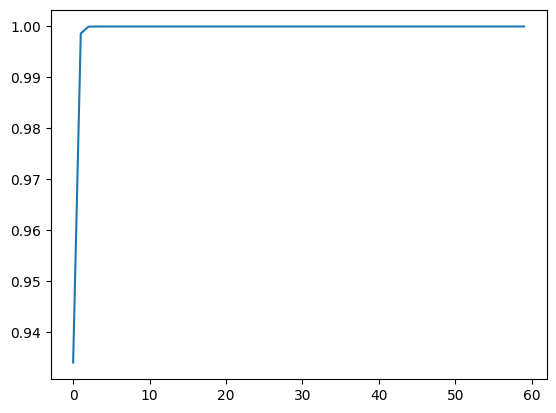

In [129]:
plt.plot(test_quad[2])

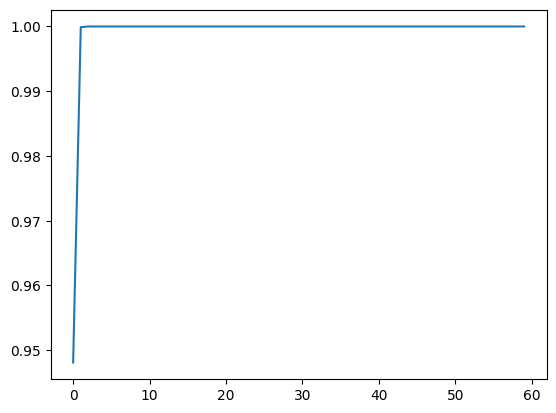

In [130]:
plt.plot(test_quad[3])

In [131]:
test_quad = find_boundary_operators(
    psi,
    80,
    120,
    2,
    30
)

ValueError: 'output_inds' must be permutation of the current tensor indices, but {'b121_2', 'b120_1', 'k120_1', 'b120_2', 'k121_1', 'k120_2', 'b122_1', 'k122_2'} != {'b121_2', 'b120_1', 'k120_1', 'k122_1', 'b120_2', 'k121_1', 'k120_2', 'b122_1', 'k122_2'}

Something weird happening here... hard to catch bug.

# Loop

In [139]:
results = {
    k: find_boundary_operators(
        psi,
        80,
        119,
        2,
        30
    )
    for k, psi in psi_dict.items()
}

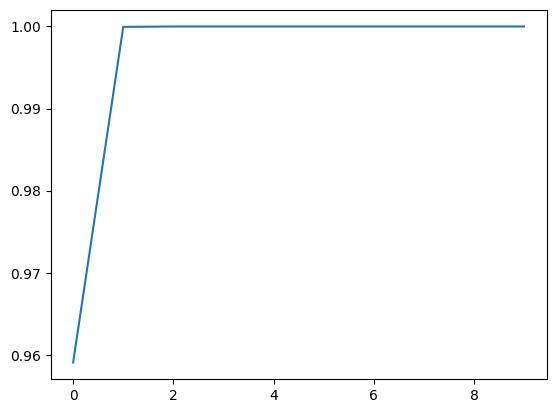

In [140]:
plt.plot(results[0.5][2][:10])

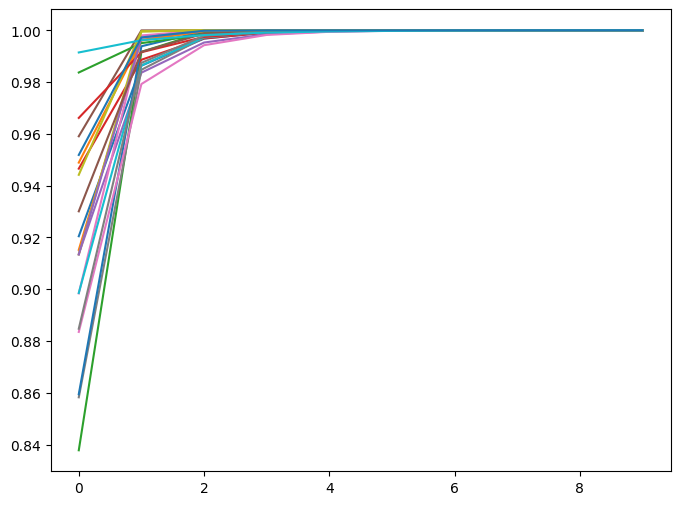

In [141]:
fig, ax = plt.subplots(figsize=(8,6))

for k, v in results.items():
    ax.plot(v[2][:10])

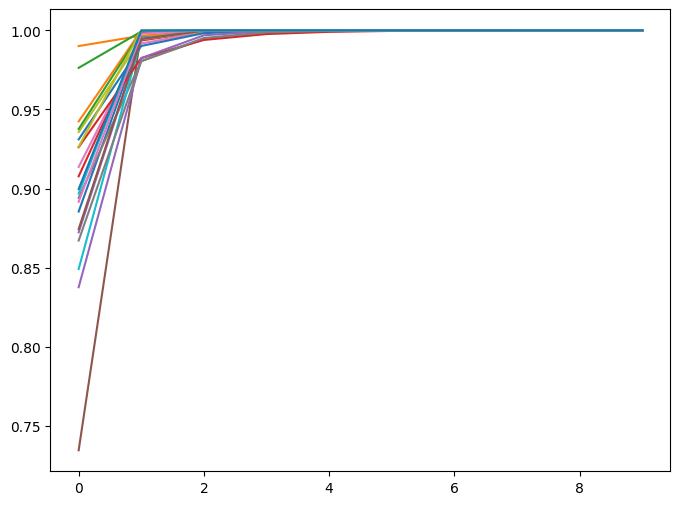

In [142]:
fig, ax = plt.subplots(figsize=(8,6))

for k, v in results.items():
    ax.plot(v[3][:10])

All look strictly increasing.

Schmidt values between left and right?

In [145]:
[
    v[4].shape for v in results.values()
]

[(1,),
 (1,),
 (1,),
 (1,),
 (5,),
 (5,),
 (5,),
 (13,),
 (15,),
 (34,),
 (48,),
 (35,),
 (15,),
 (15,),
 (15,),
 (9,),
 (9,),
 (9,),
 (5,),
 (5,),
 (5,)]

In [146]:
[
    results[k][4][1] for k in results if k > 0.3
]

[1.9314834153342695e-11,
 1.9730836649175657e-09,
 9.26437536479949e-08,
 2.5839500410613846e-06,
 5.005891369910438e-05,
 0.0007457119788328016,
 0.004713817229073482,
 0.000994261402155749,
 0.00021181965109557272,
 4.7825502232833864e-05,
 1.1539714198877633e-05,
 2.9897891237273376e-06,
 8.304567274222232e-07,
 2.4632769418380383e-07,
 7.76582554443601e-08,
 2.5898275475171646e-08,
 9.094842219538445e-09]

Can approximate as disconnected in all cases.

In [147]:
left_right_cut_schmidt_values = [
    v[4][0] for v in results.values()
]

In [148]:
left_right_cut_schmidt_values

[0.0625000000000003,
 0.06250039209597075,
 0.06250634533533128,
 0.06253274986913199,
 0.06260642381241015,
 0.06276963638976046,
 0.06308622346941764,
 0.06365162135702022,
 0.06460689740397581,
 0.06610886626525805,
 0.008071883158550284,
 0.2730534010216934,
 0.3748709225139975,
 0.45870293386179284,
 0.5275412278563187,
 0.5844214900072442,
 0.6318364311424035,
 0.6717181659648692,
 0.7055508407967788,
 0.7344797187104125,
 0.7593962181773144]

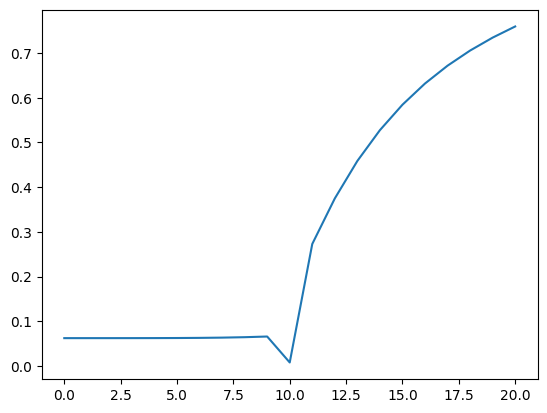

In [150]:
plt.plot(left_right_cut_schmidt_values)

In [155]:
final_scores = list()

for i, k in enumerate(results.keys()):
    final_scores.append(
        results[k][2][-1]
        *results[k][3][-1]
        *left_right_cut_schmidt_values[i]
    )

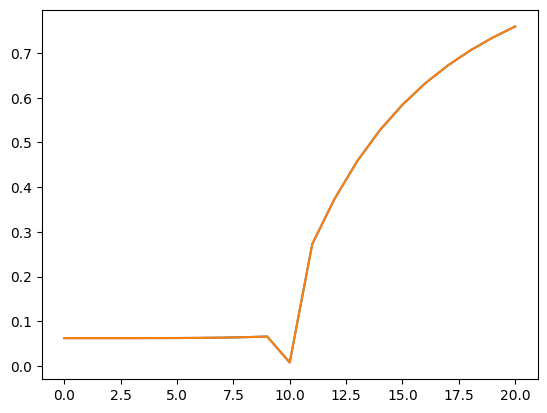

In [157]:
plt.plot(final_scores)
plt.plot(left_right_cut_schmidt_values)

In [203]:
psi.schmidt_values(80)

array([0.5, 0.5])

In [204]:
np.sum(psi.schmidt_values(80)**2)*np.sum(psi.schmidt_values(121)**2)

0.24999999999999745

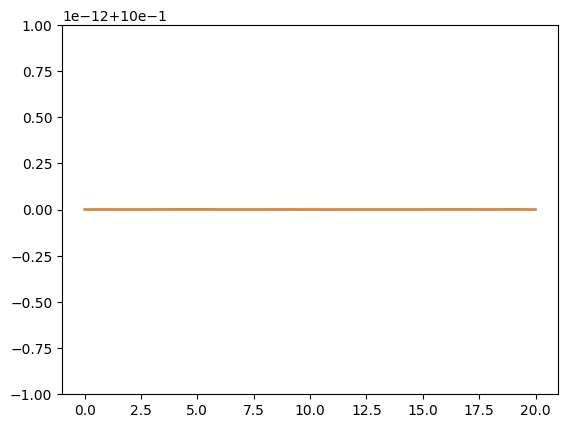

In [158]:
plt.plot([v[2][-1] for v in results.values()])
plt.plot([v[3][-1] for v in results.values()])

In [159]:
[
    [v[2][-1] for v in results.values()],
    [v[3][-1] for v in results.values()]
]

[[0.9999999999999999,
  0.9999999999999999,
  1.0,
  1.0000000000000002,
  1.0000000000000004,
  1.0000000000000009,
  1.0000000000000002,
  1.0000000000000002,
  1.0000000000000002,
  1.0,
  0.9999999999999994,
  0.9999999999999998,
  1.0,
  1.0,
  1.0,
  1.0000000000000002,
  1.0000000000000004,
  1.0000000000000004,
  1.0,
  1.0000000000000009,
  0.9999999999999997],
 [1.0000000000000002,
  1.0,
  0.9999999999999996,
  1.0,
  1.0,
  0.9999999999999998,
  0.9999999999999998,
  0.9999999999999997,
  1.0,
  1.0000000000000002,
  1.0000000000000004,
  1.0,
  0.9999999999999996,
  0.9999999999999998,
  1.0,
  1.0,
  0.9999999999999998,
  1.0,
  1.0000000000000002,
  0.9999999999999998,
  1.0]]

So the only 'error' is coming from the left-right schmidt value, ok.

# Find traditional environment matrices

In [160]:
psi

MatrixProductState(tensors=200, indices=399, L=200, max_bond=2)

In [161]:
symmetry_sites = list(range(80, 120))
num_boundary_sites = 2
all_sites = list(range(80-num_boundary_sites, 120+num_boundary_sites))

In [162]:
rho = psi.partial_trace_to_mpo(
    all_sites,
    rescale_sites=False
)

In [163]:
rho.tensors

(Tensor(shape=(4, 2, 2), inds=('_649339AAABb', 'k78', 'b78'), tags=oset(['I78'])),
 Tensor(shape=(4, 4, 2, 2), inds=('_649339AAABb', '_649339AAABc', 'k79', 'b79'), tags=oset(['I79'])),
 Tensor(shape=(4, 4, 2, 2), inds=('_649339AAABc', '_649339AAABd', 'k80', 'b80'), tags=oset(['I80'])),
 Tensor(shape=(4, 4, 2, 2), inds=('_649339AAABd', '_649339AAABe', 'k81', 'b81'), tags=oset(['I81'])),
 Tensor(shape=(4, 4, 2, 2), inds=('_649339AAABe', '_649339AAABf', 'k82', 'b82'), tags=oset(['I82'])),
 Tensor(shape=(4, 4, 2, 2), inds=('_649339AAABf', '_649339AAABg', 'k83', 'b83'), tags=oset(['I83'])),
 Tensor(shape=(4, 4, 2, 2), inds=('_649339AAABg', '_649339AAABh', 'k84', 'b84'), tags=oset(['I84'])),
 Tensor(shape=(4, 4, 2, 2), inds=('_649339AAABh', '_649339AAABi', 'k85', 'b85'), tags=oset(['I85'])),
 Tensor(shape=(4, 4, 2, 2), inds=('_649339AAABi', '_649339AAABj', 'k86', 'b86'), tags=oset(['I86'])),
 Tensor(shape=(4, 4, 2, 2), inds=('_649339AAABj', '_649339AAABk', 'k87', 'b87'), tags=oset(['I87'])),

In [164]:
rho

MatrixProductOperator(tensors=44, indices=131, L=200, max_bond=4)

In [165]:
rho.tensors[20]

Tensor(shape=(4, 4, 2, 2), inds=('_649339AAABu', '_649339AAABv', 'k98', 'b98'), tags=oset(['I98']))

In [166]:
help(psi.copy)

Help on method copy in module quimb.tensor.tensor_core:

copy(virtual=False, deep=False) method of quimb.tensor.tensor_1d.MatrixProductState instance
    Copy this ``TensorNetwork``. If ``deep=False``, (the default), then
    everything but the actual numeric data will be copied.



In [167]:
psi_2 = psi.copy(deep=True)

In [168]:
symmetry_tags = [f'I{i}' for i in symmetry_sites]

In [172]:
for t in psi_2.select(symmetry_tags, which='any'):
    t.conj(inplace=True)

In [183]:
psi_b = (
    psi
    .conj()
    .reindex({f'k{i}':f'b{i}' for i in all_sites})
)

In [184]:
x_gates = [
    x_gate.copy().reindex({'b': f'b{i}', 'k': f'k{i}'})
    for i in symmetry_sites
]

In [185]:
final = (
    qtn.tensor_core.TensorNetwork(
        [
            psi_2,
            psi_b,
            *x_gates
        ]
    )
    .contract()
)

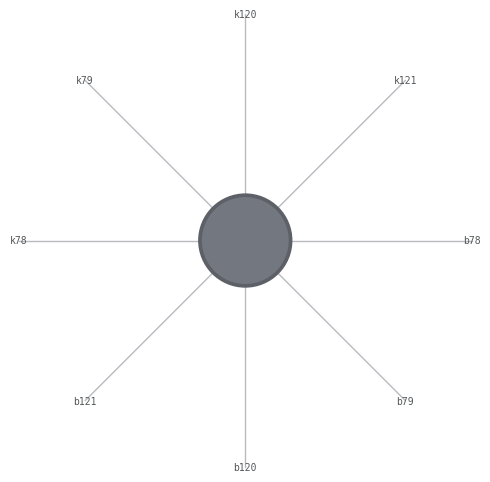

In [186]:
final.draw()

In [188]:
split_final = final.split(
    left_inds=[
        'b79',
        'b78',
        'k79',
        'k78'
    ],
    absorb=None,
    bond_ind='s'
)

In [192]:
split_final.tensors[1].data

array([0.25])

In [193]:
split_final.tensors[0]

Tensor(shape=(2, 2, 2, 2, 1), inds=('b79', 'b78', 'k79', 'k78', 's'), tags=oset(['I0', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'I10', 'I11', 'I12', 'I13', 'I14', 'I15', 'I16', 'I17', 'I18', 'I19', 'I20', 'I21', 'I22', 'I23', 'I24', 'I25', 'I26', 'I27', 'I28', 'I29', 'I30', 'I31', 'I32', 'I33', 'I34', 'I35', 'I36', 'I37', 'I38', 'I39', 'I40', 'I41', 'I42', 'I43', 'I44', 'I45', 'I46', 'I47', 'I48', 'I49', 'I50', 'I51', 'I52', 'I53', 'I54', 'I55', 'I56', 'I57', 'I58', 'I59', 'I60', 'I61', 'I62', 'I63', 'I64', 'I65', 'I66', 'I67', 'I68', 'I69', 'I70', 'I71', 'I72', 'I73', 'I74', 'I75', 'I76', 'I77', 'I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121', 'I122', 'I123', 'I124', 'I125', 'I126', 'I127', 'I128', 'I129', 'I130', 'I131', 'I132', 'I133', 'I134', 'I135', 'I136', 'I137', 'I138', 'I139', 'I140', 'I141', 'I142', 'I143', 'I144', 'I145', 'I146', 'I147', 'I148', 'I149', 'I150', 'I151', 'I152', 'I153', 'I154', 'I155', 'I156', 'I157', 'I158', 'I159', 'I160', 'I161', 'I162', 'I163', 'I164', 'I165', 'I166', 'I167', 'I168', 'I169', 'I170', 'I171', 'I172', 'I173', 'I174', 'I175', 'I176', 'I177', 'I178', 'I179', 'I180', 'I181', 'I182', 'I183', 'I184', 'I185', 'I186', 'I187', 'I188', 'I189', 'I190', 'I191', 'I192', 'I193', 'I194', 'I195', 'I196', 'I197', 'I198', 'I199']), left_inds=('b79', 'b78', 'k79', 'k78'))

In [194]:
left_env_matrix = split_final.tensors[0].isel({'s': 0})
right_env_matrix = split_final.tensors[2].isel({'s': 0})

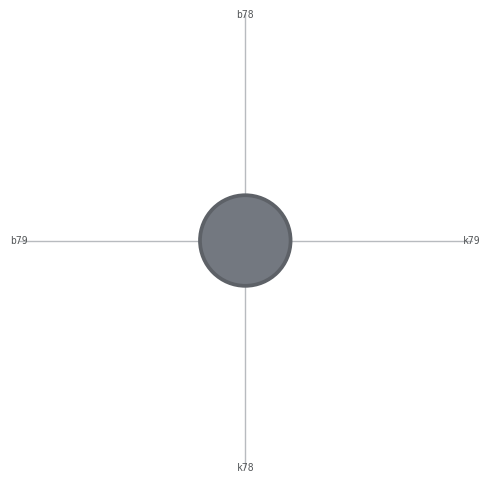

In [195]:
left_env_matrix.draw()

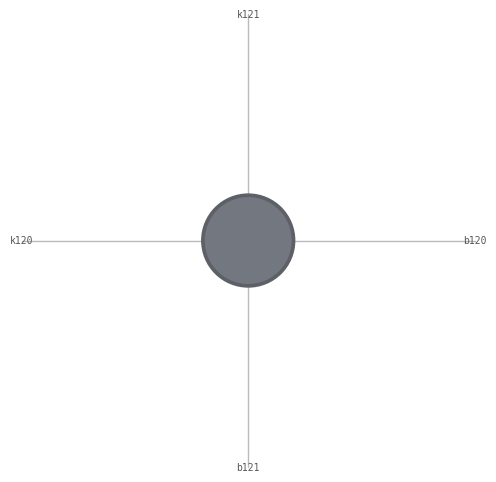

In [196]:
right_env_matrix.draw()

In [199]:
np.sum(right_env_matrix.singular_values(
    left_inds=[
        'k120',
        'k121'
    ]
))

2.0

In [206]:
np.sum(left_env_matrix.singular_values(
    left_inds=[
        'k78',
        'k79'
    ]
))

2.0

## Make function

In [207]:
x_gates = [
    x_gate.copy().reindex({'b': f'b{i}', 'k': f'k{i}'})
    for i in symmetry_sites
]

In [213]:
def get_direct_environment_matrices(psi, leftmost_symmetry_site,
    rightmost_symmetry_site, num_boundary_sites):
    
    symmetry_sites = list(range(leftmost_symmetry_site, rightmost_symmetry_site+1))
    all_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    left_boundary_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        leftmost_symmetry_site
    ))

    right_boundary_sites = list(range(
        rightmost_symmetry_site+1,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    psi_2 = psi.copy(deep=True)
    symmetry_tags = [f'I{i}' for i in symmetry_sites]
    for t in psi_2.select(symmetry_tags, which='any'):
        t.conj(inplace=True)

    psi_b = (
        psi
        .conj()
        .reindex({f'k{i}':f'b{i}' for i in all_sites})
    )

    leftright_env_matrix = (
        qtn.tensor_core.TensorNetwork(
            [
                psi_2,
                psi_b,
                *x_gates
            ]
        )
        .contract()
    )

    left_boundary_indices = [
        f'{bk}{i}'
        for bk in ['b', 'k']
        for i in left_boundary_sites
    ]

    svd = leftright_env_matrix.split(
        left_inds=left_boundary_indices,
        absorb=None,
        bond_ind='s'
    )

    left_right_singular_vals = svd.tensors[1].data

    left_env_matrix = svd.tensors[0].isel({'s': 0})
    right_env_matrix = svd.tensors[2].isel({'s': 0})

    return (left_env_matrix, right_env_matrix, left_right_singular_vals)

## Loop and check

In [214]:
leftmost_symmetry_site = 80
rightmost_symmetry_site = 119
num_boundary_sites = 2

direct_env_matrices = dict()

for k, psi in psi_dict.items():
    direct_env_matrices[k] = get_direct_environment_matrices(
        psi,
        leftmost_symmetry_site,
        rightmost_symmetry_site,
        num_boundary_sites
    )

Check singular values

In [215]:
[
    direct_env_matrices[k][2].shape
    for k in psi_dict
]

[(1,),
 (1,),
 (1,),
 (1,),
 (3,),
 (3,),
 (3,),
 (6,),
 (6,),
 (6,),
 (10,),
 (10,),
 (6,),
 (6,),
 (6,),
 (5,),
 (5,),
 (5,),
 (3,),
 (3,),
 (3,)]

In [216]:
[
    direct_env_matrices[k][2][1]
    for k in psi_dict
    if k > 0.3
]

[6.243272950547893e-11,
 5.65081076707009e-09,
 2.281561510193948e-07,
 5.284834328252693e-06,
 8.125913443494845e-05,
 0.0008966905772413761,
 0.0239165465373106,
 0.0008055371133946098,
 0.00017999647025668226,
 4.192912492518736e-05,
 1.035450766456086e-05,
 2.7302380914124745e-06,
 7.687159248343548e-07,
 2.3046223988444833e-07,
 7.328106352520194e-08,
 2.460947088475112e-08,
 8.692129754319342e-09]

Small singular values again.

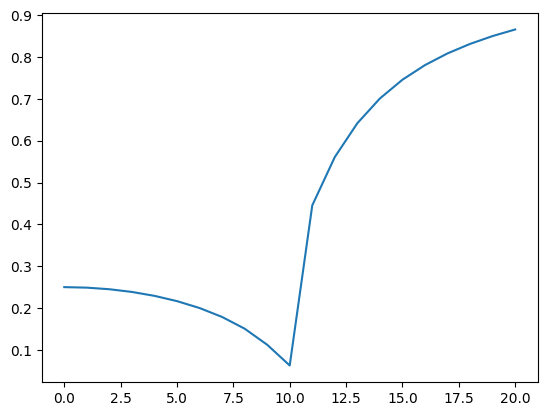

In [218]:
plt.plot([
    direct_env_matrices[k][2][0]
    for k in psi_dict
])

Qualitatively similar to previous left/right schmidt value.

Loop and check expectations

In [224]:
reindexing_dict = {
    'k120_1': 'k120',
    'k121_1': 'k121',
    'b120_1': 'b120',
    'b121_1': 'b121',
    'k120_2': 'k120',
    'k121_2': 'k121',
    'b120_2': 'b120',
    'b121_2': 'b121'
}

In [242]:
comparison_results = dict()

for k in results:
    triple = direct_env_matrices[k]

    left_env_matrix = triple[0]
    right_env_matrix = triple[1]

    expected_left_score = np.sum(left_env_matrix.singular_values(
        left_inds=[
            'k78',
            'k79'
        ]
    ))

    expected_right_score = np.sum(right_env_matrix.singular_values(
        left_inds=[
        'k120',
        'k121'
        ]
    ))

    left_boundary_ops, right_boundary_ops, *_ = results[k]

    left_scores = list()
    for op in left_boundary_ops:
        clean_op = op.reindex(reindexing_dict)
        score = (clean_op & left_env_matrix) ^ ...
        left_scores.append(score)

    right_scores = list()
    for op in right_boundary_ops:
        clean_op = op.reindex(reindexing_dict)
        score = (clean_op & right_env_matrix) ^ ...
        right_scores.append(np.abs(score))

    out = [
        #expected_left_score,
        expected_right_score,
        #left_scores,
        right_scores
    ]

    comparison_results[k] = out

In [241]:
comparison_results[0.5][3][0]

0.7408468301168499

In [239]:
left_boundary_ops

[Tensor(shape=(2, 2, 2, 2), inds=('k120_2', 'k121_2', 'b120_1', 'b121_1'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121'])),
 Tensor(shape=(2, 2, 2, 2), inds=('k120_1', 'k121_1', 'b120_2', 'b121_2'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']))]

In [243]:
comparison_results

{0.0: [2.0, [0.7408468301167718, 0.7410981537851034]],
 0.1: [2.0, [0.7408468301167702, 0.7410981537850985]],
 0.2: [2.0, [0.7408468301167711, 0.7410981537851045]],
 0.3: [2.0, [0.7408468301167652, 0.7410981537850979]],
 0.4: [2.0000000000000004, [0.7408468301167743, 0.7410981537851055]],
 0.5: [1.9999999999999998, [0.7408468301168499, 0.741098153785193]],
 0.6: [2.0, [0.7408468300007799, 0.7410981536689856]],
 0.7: [1.9999999999994071, [0.7408468852349412, 0.7410982089570856]],
 0.8: [1.9999999830096151, [0.7408355528800423, 0.741086866953354]],
 0.9: [1.9998643750732727, [0.7419810485498023, 0.7422332499285058]],
 1.0: [1.136849238205557, [0.15079192773928557, 0.48765457942232326]],
 1.1: [1.0010017363468666, [0.1687677250176558, 0.4577118578113216]],
 1.2: [1.000000797485957, [0.1686113763002927, 0.4577081546157269]],
 1.3: [1.0000002503259313, [0.16861127868566966, 0.45770828977805766]],
 1.4: [1.0000000873595525, [0.1686112496165155, 0.45770833003225664]],
 1.5: [1.000000033422035